# Task 3 — Step 1: ERM Baseline (reused from Task 2, not retrained)

**Domain generalisation (DG).** Photo, Art Painting and Cartoon are labelled source domains. **Sketch is unseen**: no Sketch image may be used by any Task 3 training, source-side diagnostic, checkpoint-selection or hyperparameter decision. It is loaded only in notebook 4. Each source domain is treated as an *environment* $e$ with risk $R_e(\theta)$.

$$\mathcal{L}_{\text{ERM}}=\frac{1}{3}\sum_{e\in\{P,A,C\}}R_e(\theta)$$

The domain-balanced batches (8 images per source per update) give every environment equal weight. This is exactly the Task 2 Source-only objective, trained with the same splits, initialisation, preprocessing, augmentation, optimiser, epoch budget, early-stopping rule and seed. The manual therefore says to **load that checkpoint rather than retrain it**: `task2_domain_adaptation/checkpoints/source_only.pth` (run Task 2 notebook 1 first).

This notebook establishes the source-side reference for DAN-DG and SAM:
- accuracy and macro-F1 on each source validation domain, their **mean**, and the **worst** domain;
- where ERM fails on the sources (confusions, failure images, per-class F1);
- how the three source domains sit in ERM's feature space.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.manifold import TSNE

from shared.src.seed import set_seed, SEED
from shared.src.pacs_data import PACSDataset, PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.plotting import use_style, SEQ_CMAP, PALETTE, DOMAIN_COLORS, NEUTRAL, INK_2, color_of, save_show, bar_labels
from shared.src.diagrams import dg_protocol_diagram
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from task2_domain_adaptation.src.evaluate import evaluate_source_validation, collect_outputs
from task3_domain_generalization.src.train import get_source_loaders

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
T2_CKPT = os.path.join(ROOT, 'task2_domain_adaptation', 'checkpoints')
RES = os.path.join(ROOT, 'task3_domain_generalization', 'results'); os.makedirs(RES, exist_ok=True)
DOM_NAMES = {'photo': 'Photo', 'art_painting': 'Art', 'cartoon': 'Cartoon'}
src_train, src_val = get_source_loaders(DATA, SPLIT)          # source domains only; Sketch is unreachable
print('loaders:', list(src_train), '| sketch loaded: no')

loaders: ['photo', 'art_painting', 'cartoon'] | sketch loaded: no


## 1. The Task 3 protocol at a glance

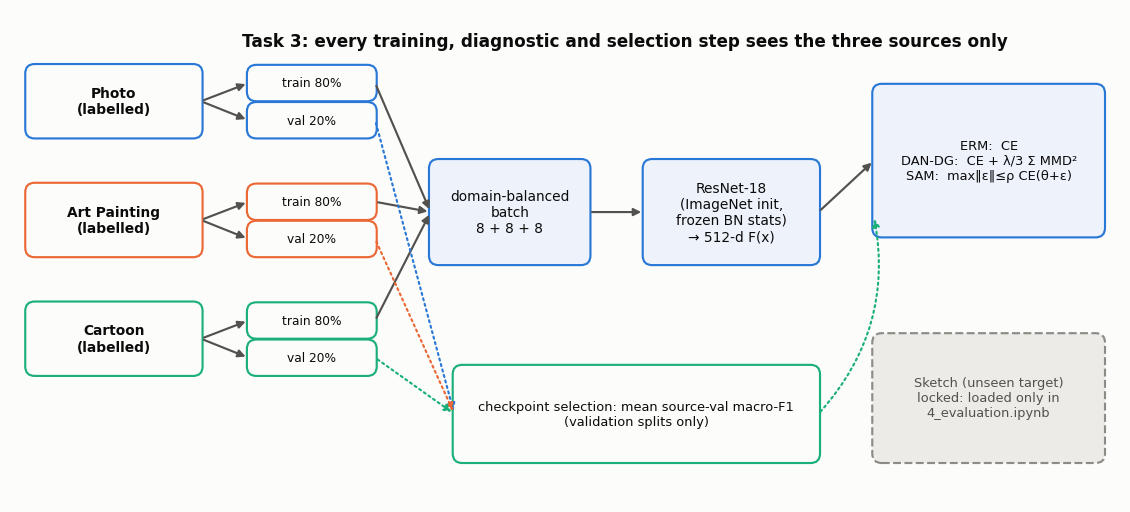

In [2]:
fig = dg_protocol_diagram()
save_show(fig, os.path.join(RES, 'task3_protocol_diagram.png'))

## 2. The observed environments
One random image per class and source domain (seed 6304), drawn from the **training** splits only. The three sources differ in texture, colour and rendering style, and all three are much richer than line drawings. Whether invariance learned across them transfers to Sketch is the question of this task.

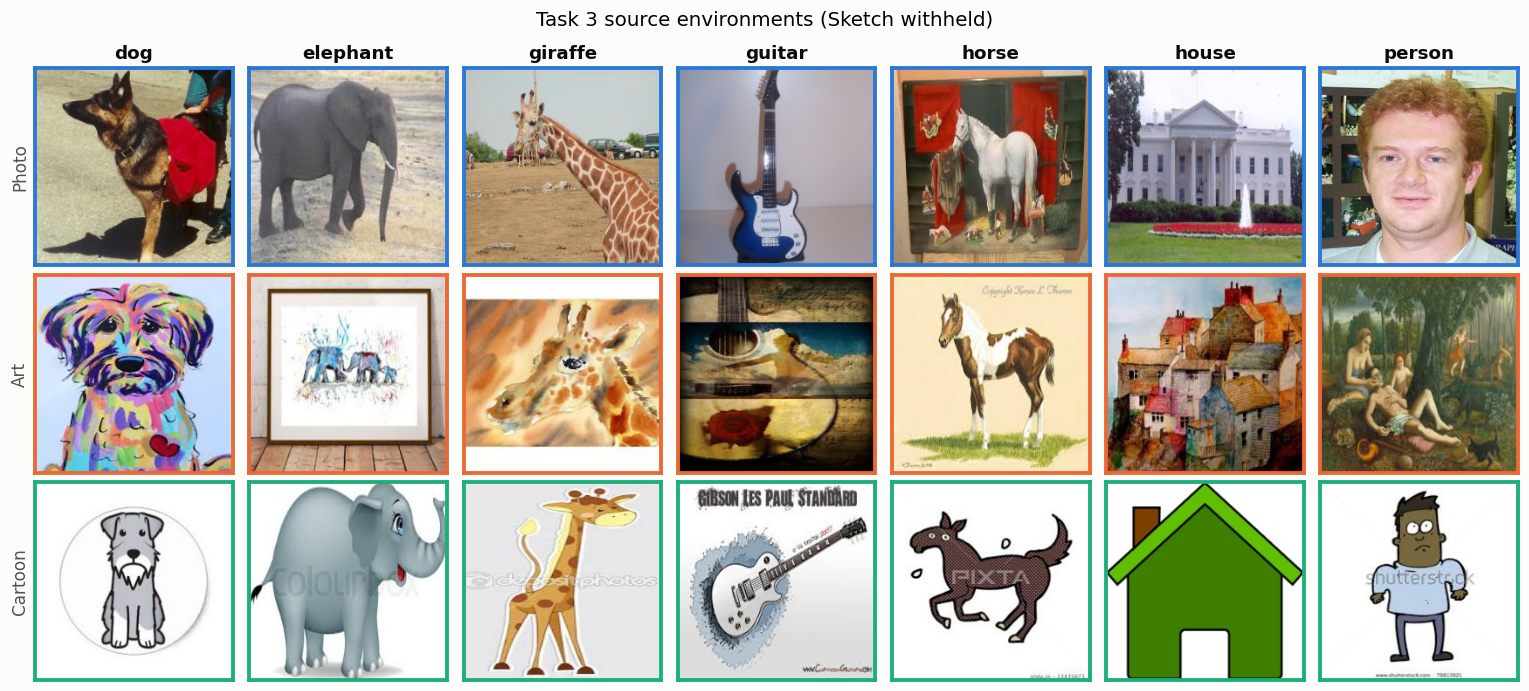

In [3]:
rng = np.random.RandomState(SEED)
split = json.load(open(SPLIT))
fig, axes = plt.subplots(3, 7, figsize=(14, 6.4))
for r, d in enumerate(PACS_SOURCE_DOMAINS):
    ds = PACSDataset(DATA, d)
    tr_idx = np.array(split[d]['train_idx']); labels = np.array([ds.samples[i][1] for i in tr_idx])
    for c in range(7):
        i = int(rng.choice(tr_idx[labels == c]))
        ax = axes[r, c]; ax.imshow(ds[i][0]); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for s in ax.spines.values(): s.set_edgecolor(DOMAIN_COLORS[d]); s.set_linewidth(2.5); s.set_visible(True)
        if r == 0: ax.set_title(PACS_CLASSES[c])
        if c == 0: ax.set_ylabel(DOM_NAMES[d], fontsize=11)
fig.suptitle('Task 3 source environments (Sketch withheld)', fontsize=13); fig.tight_layout()
save_show(fig, os.path.join(RES, 'task3_source_gallery.png'))

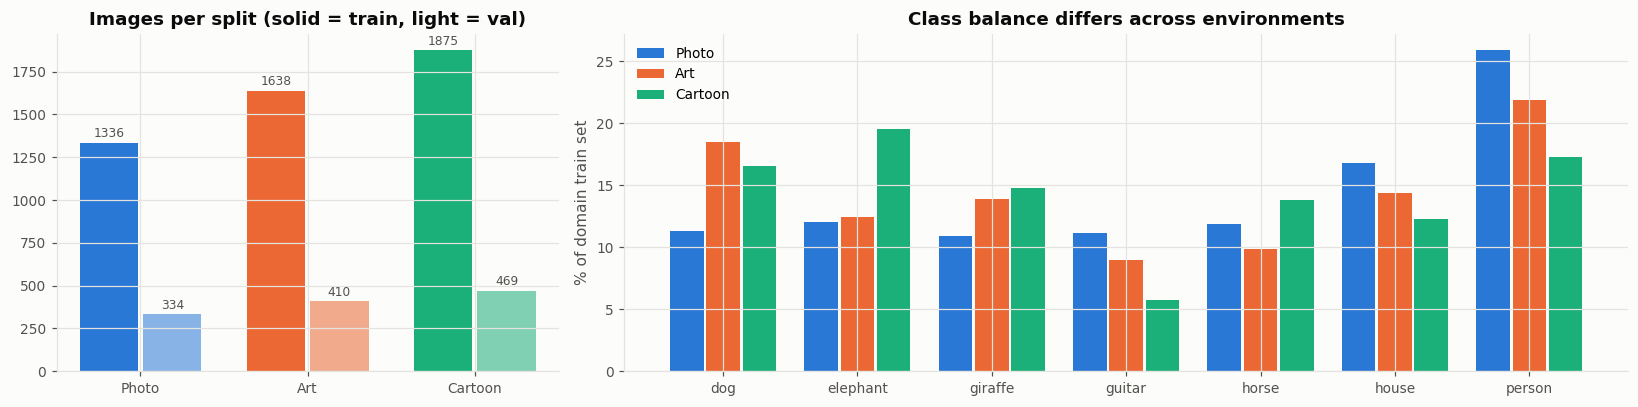

total  dog  elephant  giraffe  guitar  horse  house  \
domain       split                                                        
photo        train   1336  151       161      146     149    159    224   
             val      334   38        41       36      37     40     56   
art_painting train   1638  303       204      228     147    161    236   
             val      410   76        51       57      37     40     59   
cartoon      train   1875  311       366      277     108    259    230   
             val      469   78        91       69      27     65     58   

                    person  
domain       split          
photo        train     346  
             val        86  
art_painting train     359  
             val        90  
cartoon      train     324  
             val        81

In [4]:
# Split sizes and class balance per source domain (train and validation)
rows = []
for d in PACS_SOURCE_DOMAINS:
    ds = PACSDataset(DATA, d); lab = np.array([l for _, l in ds.samples])
    for part in ['train', 'val']:
        cnt = np.bincount(lab[split[d][f'{part}_idx']], minlength=7)
        rows.append({'domain': d, 'split': part, 'total': cnt.sum(), **dict(zip(PACS_CLASSES, cnt))})
sizes = pd.DataFrame(rows).set_index(['domain', 'split'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 3.8), gridspec_kw={'width_ratios': [1, 2]})
x = np.arange(3); w = 0.38
for k, part in enumerate(['train', 'val']):
    b = a1.bar(x + (k - 0.5) * w, [sizes.loc[(d, part), 'total'] for d in PACS_SOURCE_DOMAINS], w * 0.92,
               color=[DOMAIN_COLORS[d] for d in PACS_SOURCE_DOMAINS], alpha=1.0 if part == 'train' else 0.55, label=part)
    bar_labels(a1, b, fmt='{:.0f}', offset=15)
a1.set_xticks(x); a1.set_xticklabels([DOM_NAMES[d] for d in PACS_SOURCE_DOMAINS]); a1.set_title('Images per split (solid = train, light = val)')
for i, d in enumerate(PACS_SOURCE_DOMAINS):
    share = sizes.loc[(d, 'train'), PACS_CLASSES].values.astype(float); share /= share.sum()
    a2.bar(np.arange(7) + (i - 1) * 0.27, 100 * share, 0.25, color=DOMAIN_COLORS[d], label=DOM_NAMES[d])
a2.set_xticks(range(7)); a2.set_xticklabels(PACS_CLASSES); a2.set_ylabel('% of domain train set'); a2.set_title('Class balance differs across environments'); a2.legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_source_split_balance.png'))
sizes

## 3. Load the ERM checkpoint (Task 2 Source-only)

In [5]:
erm = ResNet18Backbone(num_classes=7).to(device)
erm.load_state_dict(torch.load(os.path.join(T2_CKPT, 'source_only.pth'), map_location=device, weights_only=True))
meta = json.load(open(os.path.join(T2_CKPT, 'source_only_history.json')))
print('ERM = Task 2 Source-only checkpoint | config:', meta['config'], '| selected epoch', meta['best_epoch'])

ERM = Task 2 Source-only checkpoint | config: {'method': 'source_only', 'lr': 0.0001, 'wd': 0.0001, 'max_epochs': 30, 'patience': 5, 'batch_per_source_domain': 8, 'train_transform': 'Resize(256,256)+RandomCrop(224)+HFlip', 'seed': 6304} | selected epoch 8


## 4. Source-validation results (the ERM reference row)

In [6]:
m = evaluate_source_validation(erm, src_val, device)
tab = pd.DataFrame({d: {'acc (%)': 100 * m[d]['acc'], 'macro-F1 (%)': 100 * m[d]['f1']} for d in PACS_SOURCE_DOMAINS}).T
tab.loc['mean'] = tab.loc[PACS_SOURCE_DOMAINS].mean()
tab.loc['worst'] = tab.loc[PACS_SOURCE_DOMAINS].min()
worst = tab.loc[PACS_SOURCE_DOMAINS, 'macro-F1 (%)'].idxmin()
print('worst source domain (macro-F1):', worst)
tab.to_csv(os.path.join(RES, 'erm_source_validation.csv'))
tab.round(2)

worst source domain (macro-F1): art_painting


,acc (%),macro-F1 (%)
photo,96.71,96.28
art_painting,91.46,91.35
cartoon,93.18,93.64
mean,93.78,93.76
worst,91.46,91.35


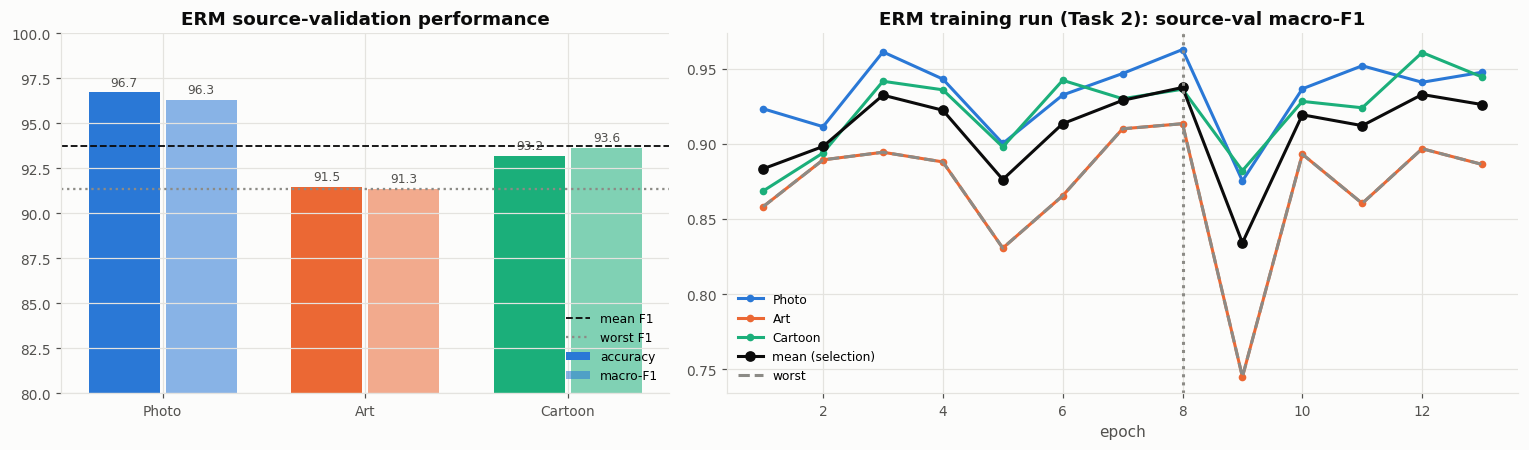

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={'width_ratios': [1, 1.3]})
x = np.arange(3); w = 0.38
b1 = a1.bar(x - w / 2, tab.loc[PACS_SOURCE_DOMAINS, 'acc (%)'], w * 0.92, color=[DOMAIN_COLORS[d] for d in PACS_SOURCE_DOMAINS], label='accuracy')
b2 = a1.bar(x + w / 2, tab.loc[PACS_SOURCE_DOMAINS, 'macro-F1 (%)'], w * 0.92, color=[DOMAIN_COLORS[d] for d in PACS_SOURCE_DOMAINS], alpha=0.55, label='macro-F1')
bar_labels(a1, b1, offset=0.2); bar_labels(a1, b2, offset=0.2)
a1.axhline(tab.loc['mean', 'macro-F1 (%)'], color='#0b0b0b', ls='--', lw=1.2, label='mean F1')
a1.axhline(tab.loc['worst', 'macro-F1 (%)'], color=NEUTRAL, ls=':', lw=1.5, label='worst F1')
a1.set_ylim(min(80, tab.values.min() - 3), 100); a1.set_xticks(x); a1.set_xticklabels([DOM_NAMES[d] for d in PACS_SOURCE_DOMAINS])
a1.set_title('ERM source-validation performance'); a1.legend(fontsize=8, loc='lower right')
H = meta['history']; ep = np.arange(1, len(H['cls_loss']) + 1)
for d in PACS_SOURCE_DOMAINS:
    a2.plot(ep, H['val_per_domain'][d]['f1'], 'o-', ms=4, color=DOMAIN_COLORS[d], label=DOM_NAMES[d])
a2.plot(ep, H['val_mean_f1'], 'o-', color='#0b0b0b', label='mean (selection)')
a2.plot(ep, np.min([H['val_per_domain'][d]['f1'] for d in PACS_SOURCE_DOMAINS], 0), '--', color=NEUTRAL, label='worst')
a2.axvline(meta['best_epoch'], color=NEUTRAL, ls=':'); a2.set_title('ERM training run (Task 2): source-val macro-F1'); a2.set_xlabel('epoch'); a2.legend(fontsize=8)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'erm_source_performance.png'))

## 5. Where ERM fails on the sources
Row-normalised confusion matrices on every source validation split, and per-class macro-F1 per domain. A class that is weak on one environment but fine on another points to domain-specific cues.

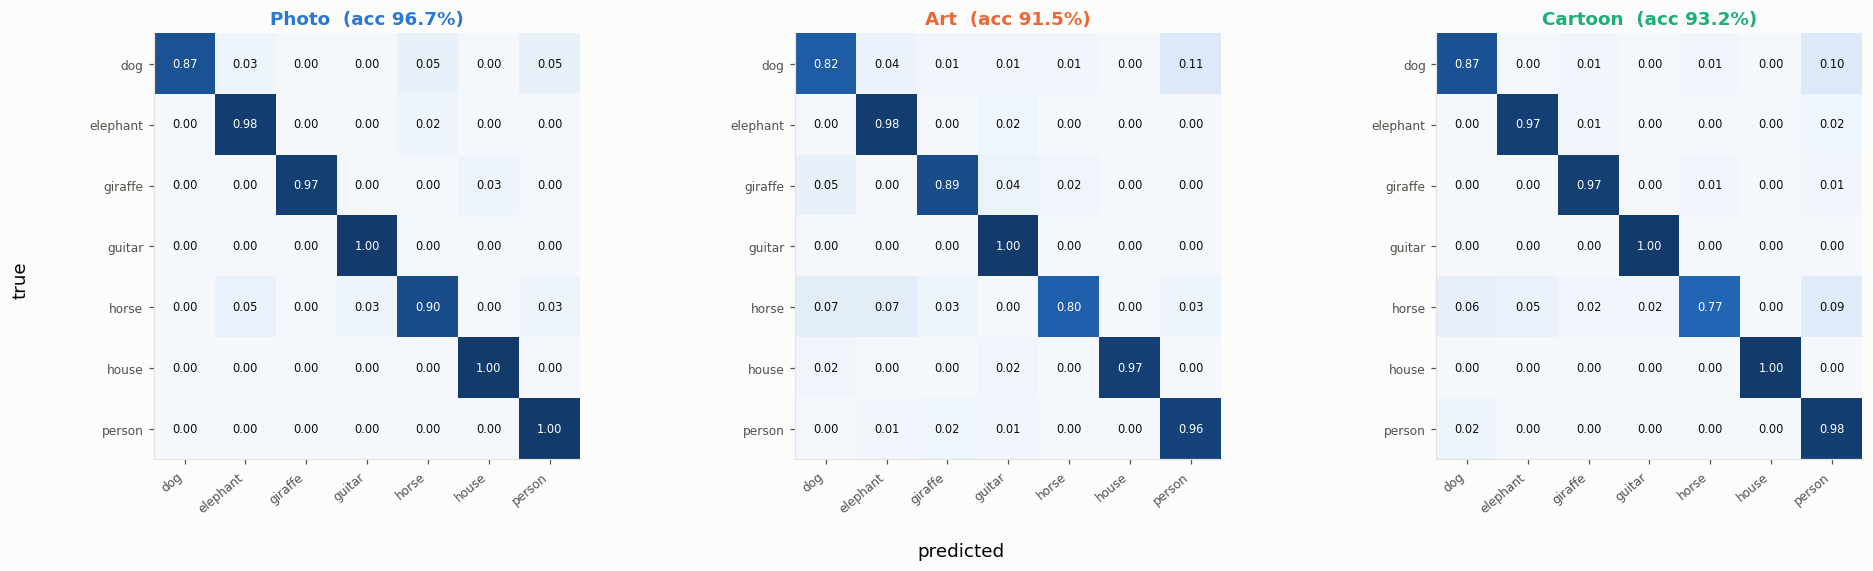

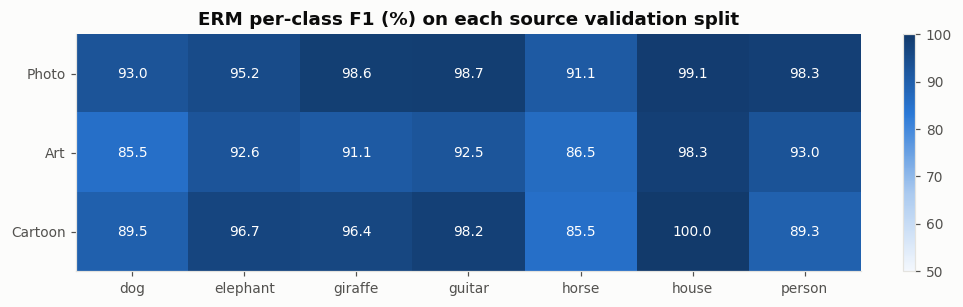

In [8]:
outs = {d: collect_outputs(erm, src_val[d], device) for d in PACS_SOURCE_DOMAINS}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
for ax, d in zip(axes, PACS_SOURCE_DOMAINS):
    lg, _, y = outs[d]; cm = confusion_matrix(y, lg.argmax(1), labels=range(7)); cmn = cm / cm.sum(1, keepdims=True)
    ax.imshow(cmn, cmap=SEQ_CMAP, vmin=0, vmax=1)
    for i in range(7):
        for j in range(7): ax.text(j, i, f'{cmn[i, j]:.2f}', ha='center', va='center', fontsize=7.5, color='white' if cmn[i, j] > 0.55 else '#0b0b0b')
    ax.set_xticks(range(7)); ax.set_xticklabels(PACS_CLASSES, rotation=40, ha='right', fontsize=8); ax.set_yticks(range(7)); ax.set_yticklabels(PACS_CLASSES, fontsize=8)
    ax.grid(False); ax.set_title(f"{DOM_NAMES[d]}  (acc {100*(lg.argmax(1)==y).mean():.1f}%)", color=DOMAIN_COLORS[d])
fig.supxlabel('predicted'); fig.supylabel('true'); fig.tight_layout()
save_show(fig, os.path.join(RES, 'erm_source_confusions.png'))
pcf1 = pd.DataFrame({DOM_NAMES[d]: 100 * f1_score(outs[d][2], outs[d][0].argmax(1), average=None, labels=range(7)) for d in PACS_SOURCE_DOMAINS}, index=PACS_CLASSES)
fig, a = plt.subplots(figsize=(10, 2.8))
im = a.imshow(pcf1.T.values, cmap=SEQ_CMAP, vmin=50, vmax=100, aspect='auto')
for i in range(3):
    for j in range(7): a.text(j, i, f'{pcf1.T.values[i, j]:.1f}', ha='center', va='center', fontsize=9, color='white' if pcf1.T.values[i, j] > 85 else '#0b0b0b')
a.set_xticks(range(7)); a.set_xticklabels(PACS_CLASSES); a.set_yticks(range(3)); a.set_yticklabels(pcf1.columns); a.grid(False)
a.set_title('ERM per-class F1 (%) on each source validation split'); fig.colorbar(im, ax=a, fraction=0.03)
save_show(fig, os.path.join(RES, 'erm_source_per_class_f1.png'))

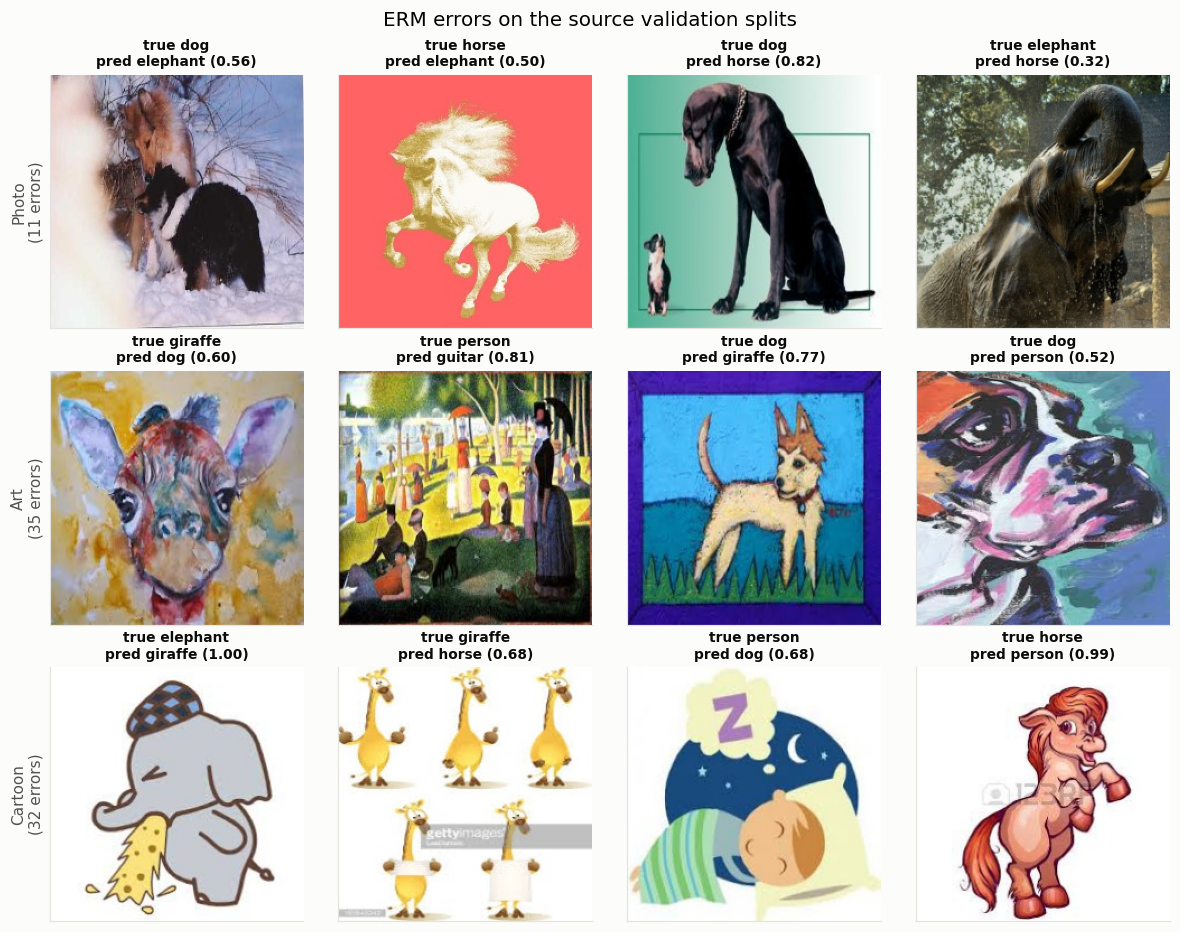

In [9]:
# Misclassified source-validation images (random, seed 6304), 4 per domain
fig, axes = plt.subplots(3, 4, figsize=(11, 8.6))
rng = np.random.RandomState(SEED)
for r, d in enumerate(PACS_SOURCE_DOMAINS):
    lg, _, y = outs[d]; p = lg.argmax(1); conf = torch.softmax(torch.tensor(lg), 1).max(1).values.numpy()
    wrong = np.where(p != y)[0]; pick = rng.choice(wrong, min(4, len(wrong)), replace=False) if len(wrong) else []
    raw = PACSDataset(DATA, d); idx = split[d]['val_idx']
    for c in range(4):
        ax = axes[r, c]; ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if c < len(pick):
            i = int(pick[c]); ax.imshow(raw[idx[i]][0]); ax.set_title(f'true {PACS_CLASSES[y[i]]}\npred {PACS_CLASSES[p[i]]} ({conf[i]:.2f})', fontsize=9)
    axes[r, 0].set_ylabel(f"{DOM_NAMES[d]}\n({len(wrong)} errors)", fontsize=10)
fig.suptitle('ERM errors on the source validation splits', fontsize=13); fig.tight_layout()
save_show(fig, os.path.join(RES, 'erm_source_failures.png'))

## 6. ERM feature space across the three sources
One t-SNE (perplexity 30, PCA init, seed 6304) of all source-validation features: left coloured by **domain**, right by **class**. If domains form separate islands, ERM's representation still encodes environment identity. That residual domain information is what DAN-DG tries to remove and what the source-separability probe in notebook 4 measures.

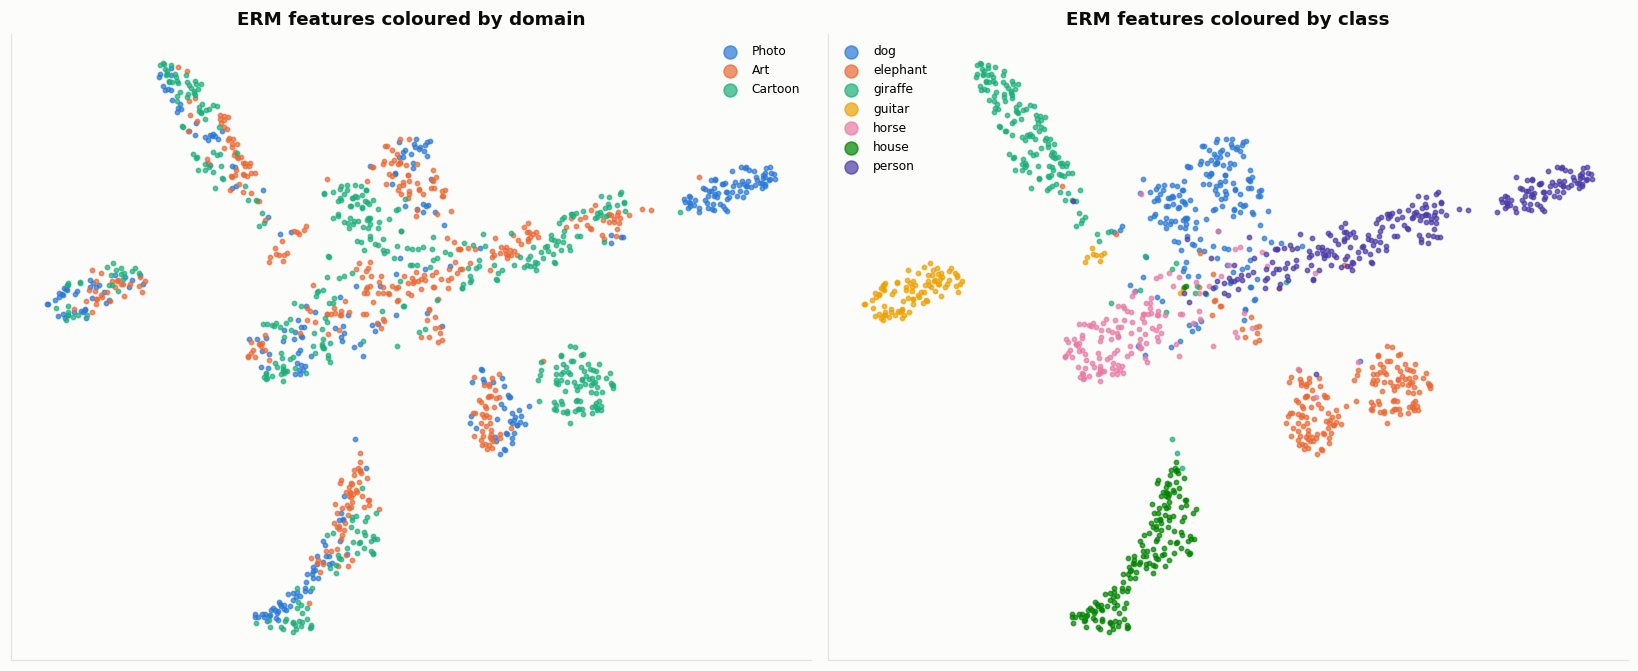

In [10]:
F_all = np.concatenate([outs[d][1] for d in PACS_SOURCE_DOMAINS]); Y_all = np.concatenate([outs[d][2] for d in PACS_SOURCE_DOMAINS])
D_all = np.concatenate([[d] * len(outs[d][2]) for d in PACS_SOURCE_DOMAINS])
E = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(F_all)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6.2))
for d in PACS_SOURCE_DOMAINS:
    a1.scatter(E[D_all == d, 0], E[D_all == d, 1], s=8, alpha=0.7, color=DOMAIN_COLORS[d], label=DOM_NAMES[d])
for c in range(7):
    a2.scatter(E[Y_all == c, 0], E[Y_all == c, 1], s=8, alpha=0.7, color=PALETTE[c], label=PACS_CLASSES[c])
a1.set_title('ERM features coloured by domain'); a2.set_title('ERM features coloured by class')
for a in (a1, a2): a.set_xticks([]); a.set_yticks([]); a.legend(markerscale=3, fontsize=8)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'erm_source_tsne.png'))

## 7. Evidence summary (source side only)
Facts only; interpretation belongs in the report. Sketch results for ERM are reported in notebook 4.

In [11]:
print(f"mean source-val macro-F1 {tab.loc['mean', 'macro-F1 (%)']:.2f}% | worst {tab.loc['worst', 'macro-F1 (%)']:.2f}% ({worst})")
print('weakest (domain, class) F1 cells:', pcf1.stack().nsmallest(4).round(1).to_dict())

mean source-val macro-F1 93.76% | worst 91.35% (art_painting)
weakest (domain, class) F1 cells: {('horse', 'Cartoon'): 85.5, ('dog', 'Art'): 85.5, ('horse', 'Art'): 86.5, ('person', 'Cartoon'): 89.3}
